# mcPHASES EDA

Overview: daily-level exploratory data analysis across five categories: Physical activity, Sleep, Symptoms & Hormones, Stress/Recovery, Background.

In [1]:
%pip install -q -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup
Install dependencies then run the merge Python scripts to produce merged CSVs.（DO NOT need to run every time.)

In [2]:
from pathlib import Path
import subprocess
import sys

repo_root = Path("..").resolve()

scripts = [
    "src/physical_activity.py",
    "src/sleep.py",
    "src/symptoms_hormones.py",
    "src/stress_recovery.py",
    "src/background.py"
]

for s in scripts:
    script_path = (repo_root / s).resolve()
    print("Running", script_path)
    subprocess.run([sys.executable, str(script_path)], cwd=repo_root, check=True)

Running D:\ML-for-Women\src\physical_activity.py
Running D:\ML-for-Women\src\sleep.py
Running D:\ML-for-Women\src\symptoms_hormones.py
Running D:\ML-for-Women\src\stress_recovery.py
Running D:\ML-for-Women\src\background.py


In [3]:
import pandas as pd
from pathlib import Path
# Load merged outputs
dfs = {}
for fname in ['../mcphases/merged/physical_activity.csv','../mcphases/merged/sleep.csv','../mcphases/merged/symptoms_hormones.csv','../mcphases/merged/stress_recovery.csv','../mcphases/merged/background.csv']:
    p = Path(fname)
    if p.exists():
        dfs[fname] = pd.read_csv(p)
        print(fname, dfs[fname].shape)
        # print (dfs[fname].dtypes)
    else:
        print('Missing', fname)

../mcphases/merged/physical_activity.csv (5552, 23)
../mcphases/merged/sleep.csv (5039, 20)
../mcphases/merged/symptoms_hormones.csv (5659, 22)
../mcphases/merged/stress_recovery.csv (13737, 24)
../mcphases/merged/background.csv (11482, 16)


## EDA: Physical activity — correlations and missingness

                          count          mean           std       min  \
id                       5552.0  2.636689e+01  1.461977e+01       1.0   
day_in_study             5552.0  3.375875e+02  4.143232e+02       1.0   
study_interval           5552.0  2.022668e+03  9.433177e-01    2022.0   
sedentary                3698.0  8.330819e+02  2.792789e+02       0.0   
lightly                  5552.0  1.630546e+02  1.054135e+02       0.0   
moderately               5552.0  1.478728e+01  2.321039e+01       0.0   
very                     5552.0  1.636311e+01  2.665534e+01       0.0   
CARDIO                   1861.0  1.778936e+01  2.394507e+01       2.0   
FAT_BURN                 4450.0  3.048449e+01  3.868246e+01       1.0   
PEAK                       78.0  1.223077e+01  1.047932e+01       2.0   
daily_calories           5549.0  2.774592e+03  1.558646e+03    1210.0   
daily_distance           5427.0  4.681252e+05  3.929340e+05       0.0   
exercise_duration        1706.0  7.790966e+06  7.85

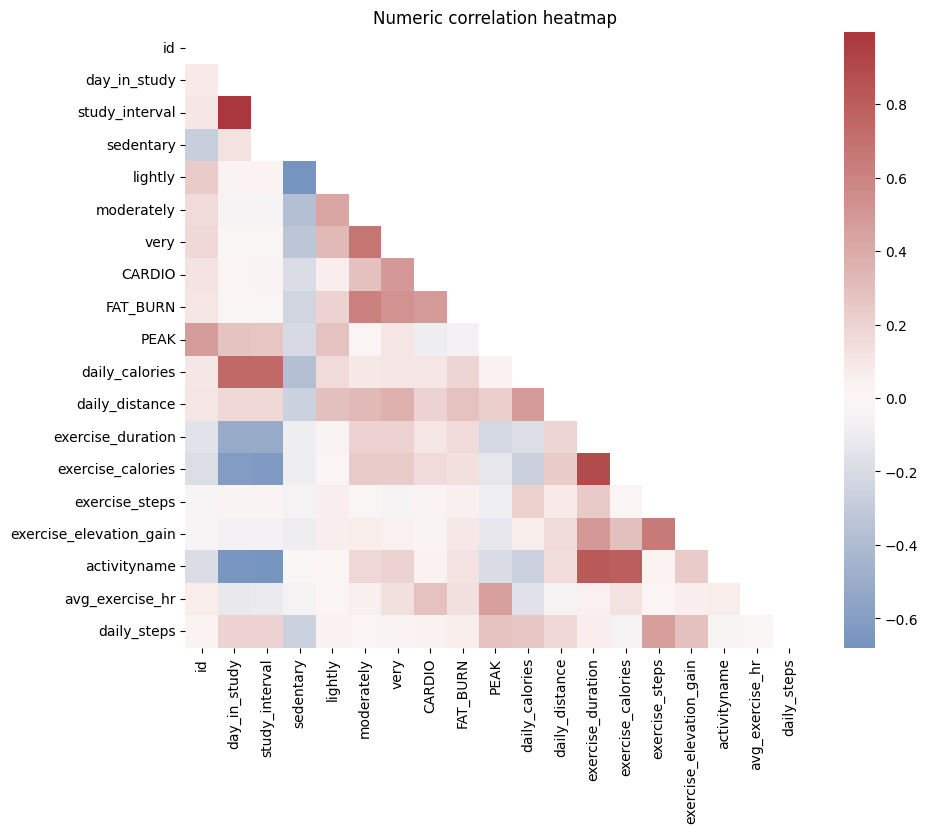

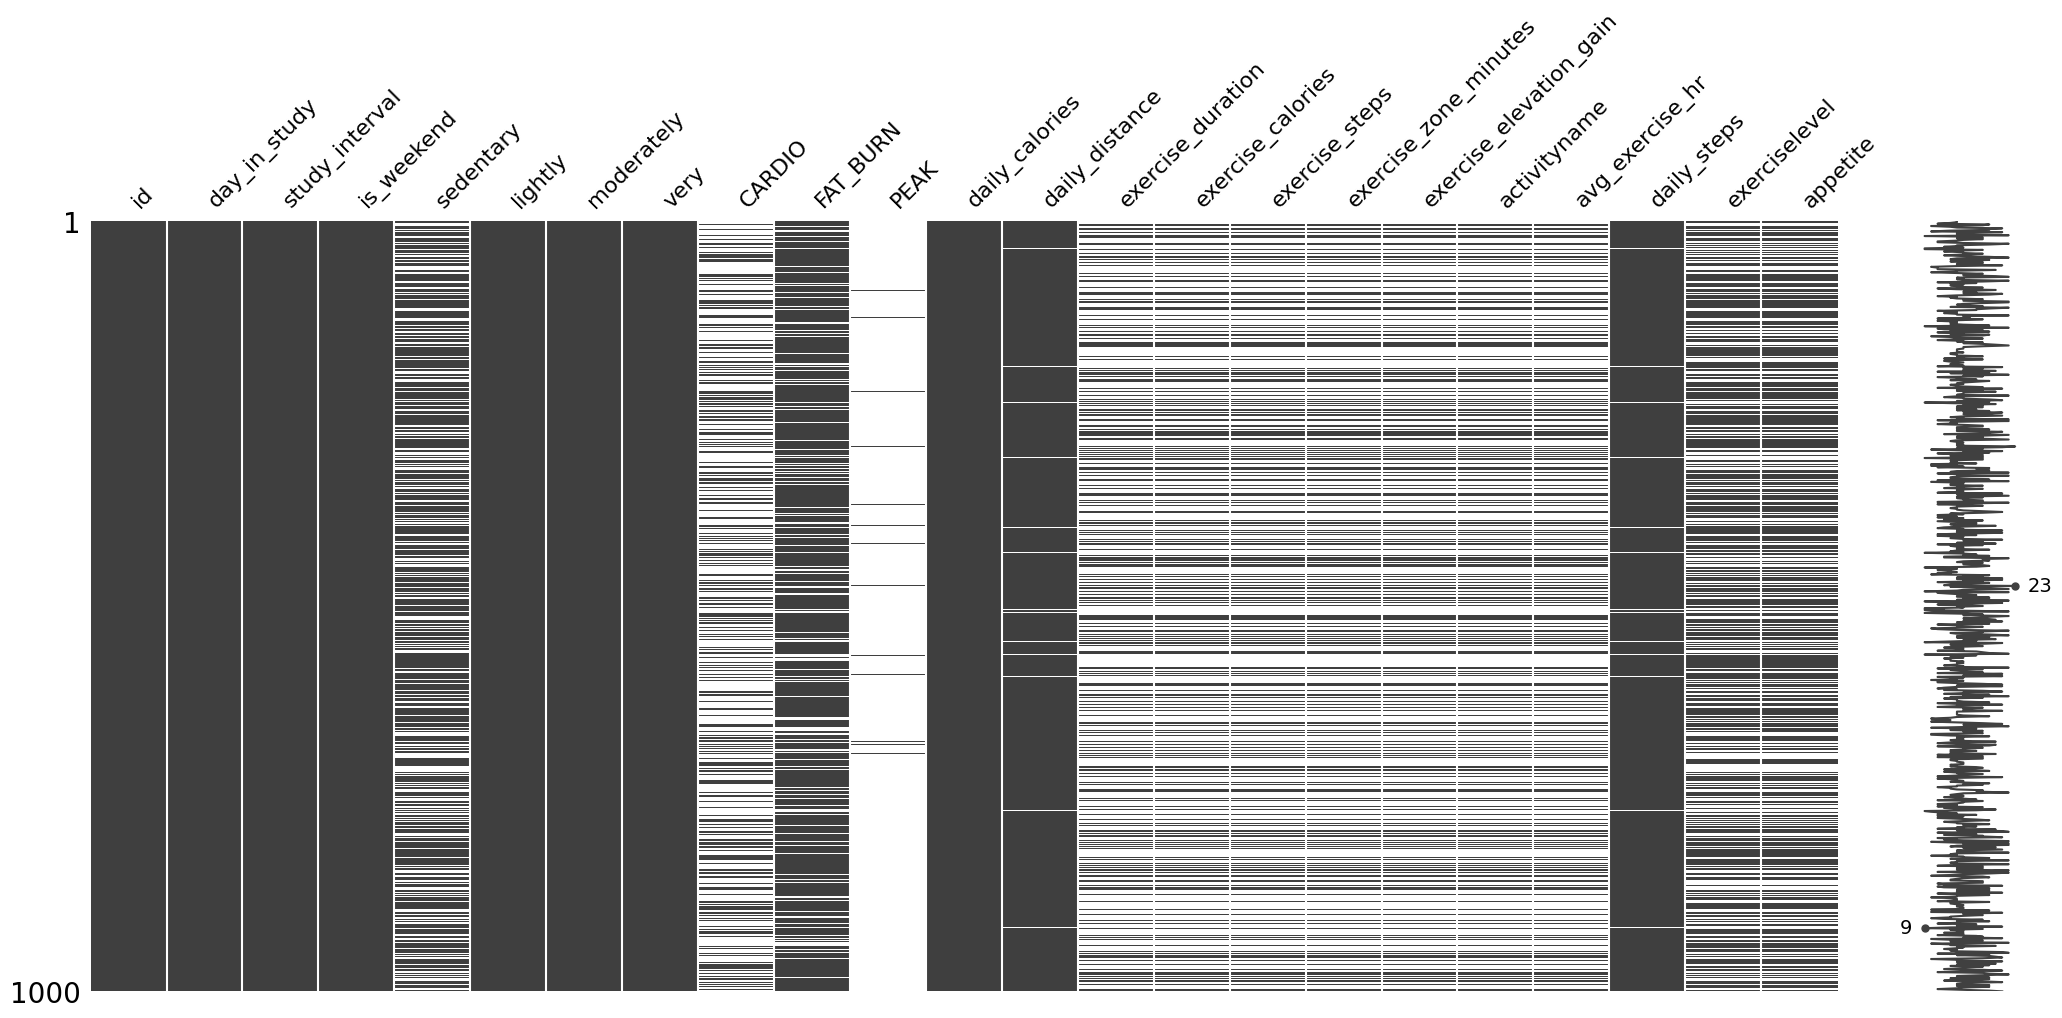

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

df = dfs.get('../mcphases/merged/physical_activity.csv')
if df is not None:
    print(df.select_dtypes(include='number').describe().T)
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0)
    plt.title('Numeric correlation heatmap')
    plt.show()
    try:
        msno.matrix(df.sample(min(1000,len(df))))
    except Exception:
        pass

## Short interpretations
Add brief interpretations per plot and domain.

## EDA: Sleep — correlations and missingness

                         count          mean           std           min  \
id                      5039.0  2.699147e+01  1.442773e+01  1.000000e+00   
day_in_study            5039.0  3.827565e+02  4.265059e+02  1.000000e+00   
minutes_asleep          5039.0  1.038775e+03  8.874154e+02  5.600000e+01   
minutes_awake           5039.0  1.442169e+02  1.259495e+02  0.000000e+00   
minutes_after_wakeup    5039.0  2.387974e+00  5.296724e+00  0.000000e+00   
time_in_bed             5039.0  1.183548e+03  1.008652e+03  6.400000e+01   
duration                5039.0  7.101290e+07  6.051914e+07  3.840000e+06   
efficiency              5039.0  9.314232e+01  7.731639e+00  1.500000e+01   
minutes_to_fall_asleep  5039.0  1.568466e-01  2.293462e+00  0.000000e+00   
overall_score           4721.0  7.680449e+01  8.364625e+00  3.000000e+01   
composition_score       3212.0  2.005184e+01  2.260111e+00  1.100000e+01   
revitalization_score    4721.0  3.766363e+01  2.768752e+01  9.000000e+00   
duration_sco

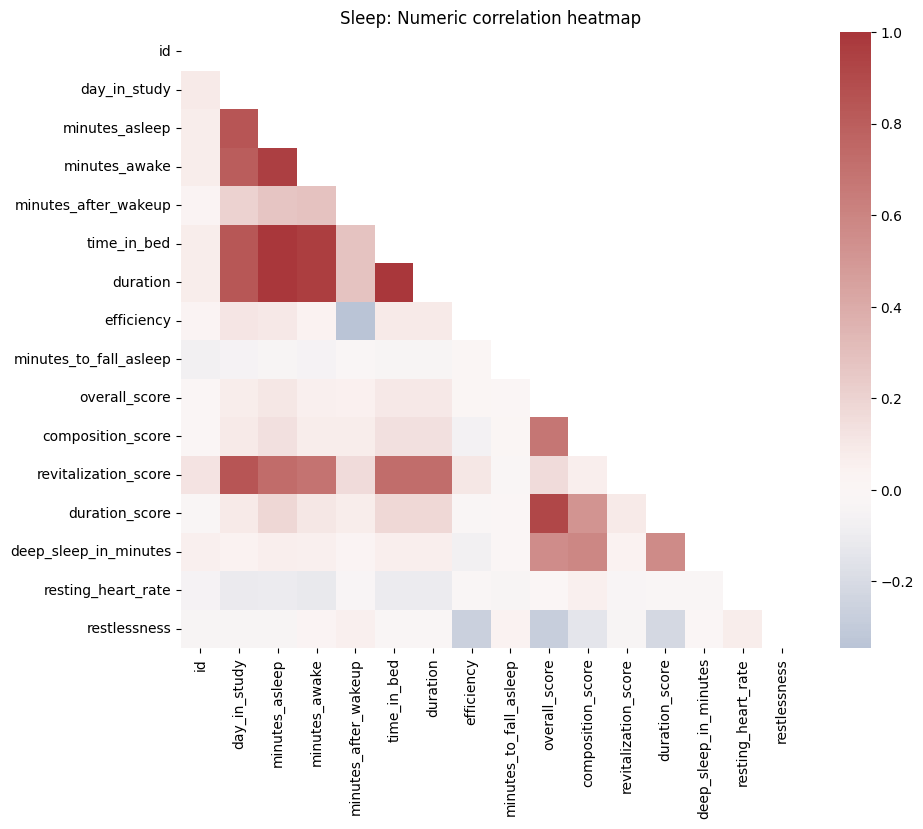

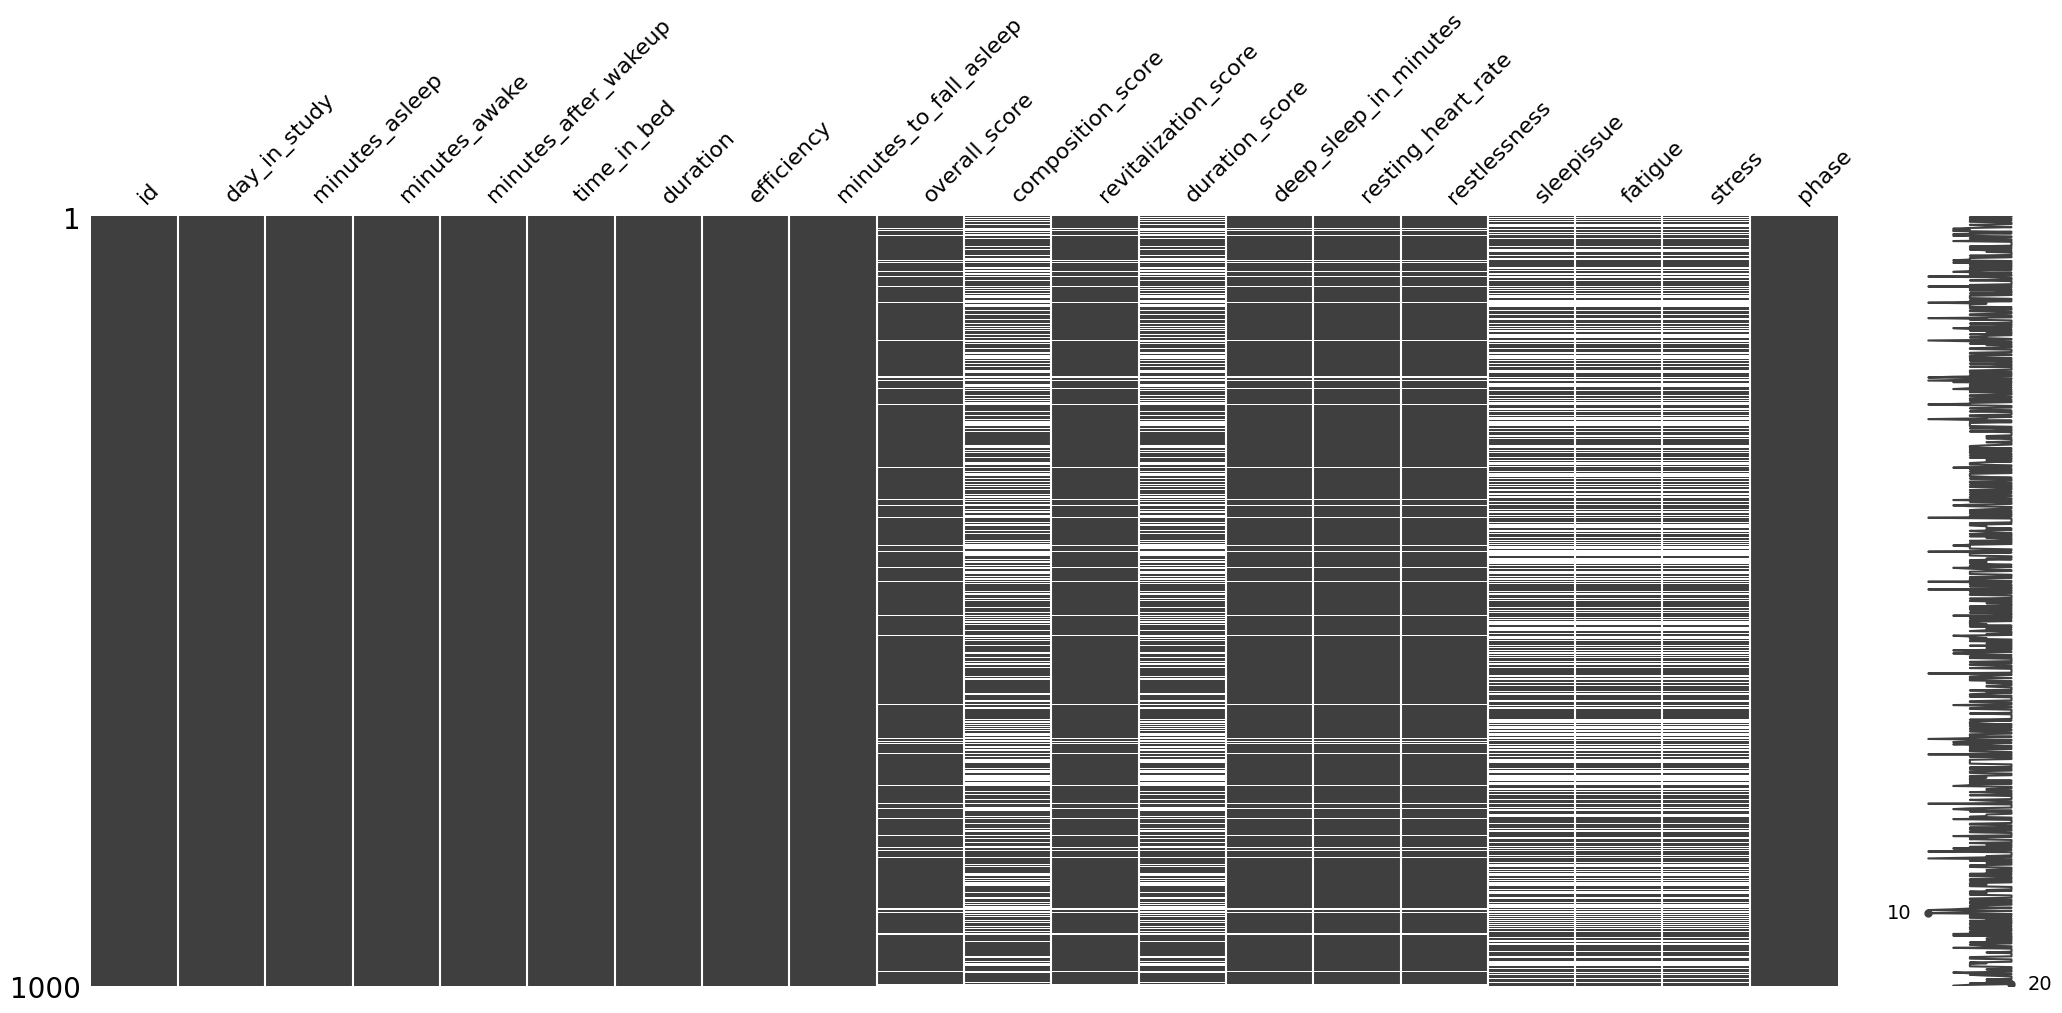

In [7]:
df = dfs.get('../mcphases/merged/sleep.csv')
if df is not None:
    print(df.select_dtypes(include='number').describe().T)
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0)
    plt.title('Sleep: Numeric correlation heatmap')
    plt.show()
    try:
        msno.matrix(df.sample(min(1000,len(df))))
    except Exception:
        pass

## EDA: Symptoms & Hormones — correlations and missingness

                               count        mean         std          min  \
id                            5659.0   26.545503   14.618883     1.000000   
day_in_study                  5659.0  347.474289  416.521099     1.000000   
lh                            5339.0    6.332609    7.888081     0.000000   
estrogen                      5338.0  128.987748  101.859259     0.000000   
pdg                           1864.0    6.229828    7.112508     1.000000   
nightly_temperature           4508.0   33.790935    0.910045    25.699286   
baseline_relative_sample_sum  4415.0  -16.887338  295.893877 -4436.313846   

                                     25%         50%         75%          max  
id                             13.000000   26.000000   41.000000    50.000000  
day_in_study                   34.000000   69.000000  893.000000  1004.000000  
lh                              2.800000    4.400000    6.900000   185.600000  
estrogen                       67.100000  100.050000  155.40000

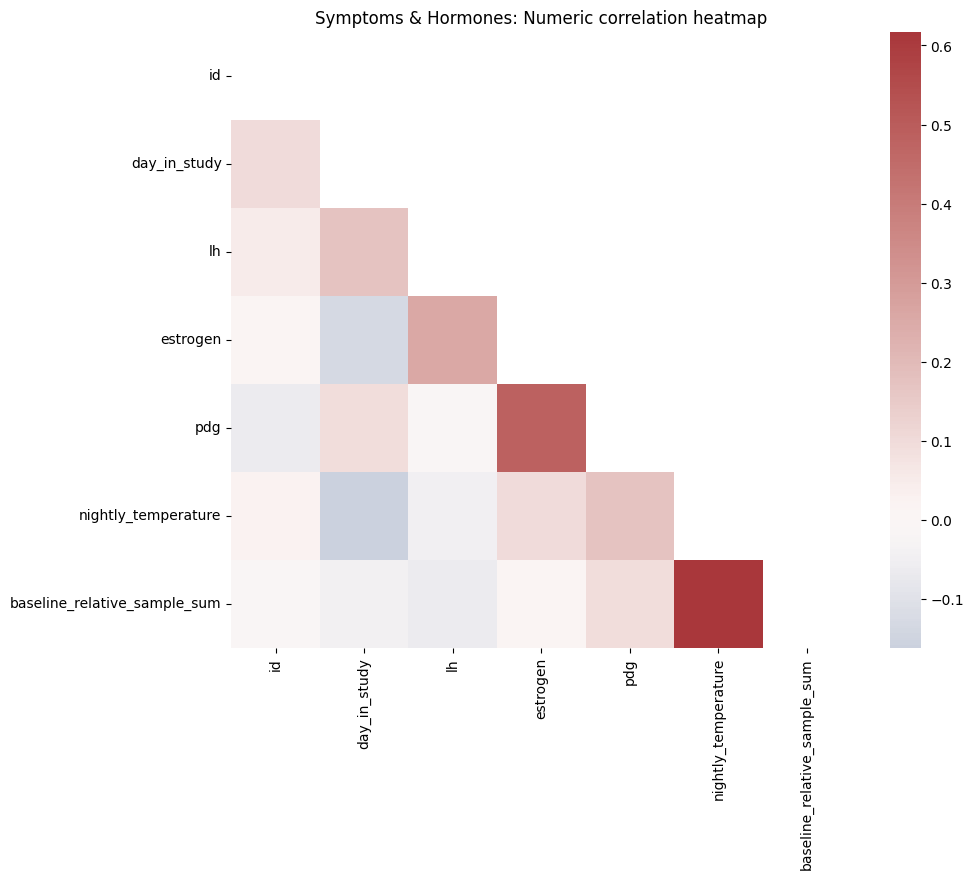

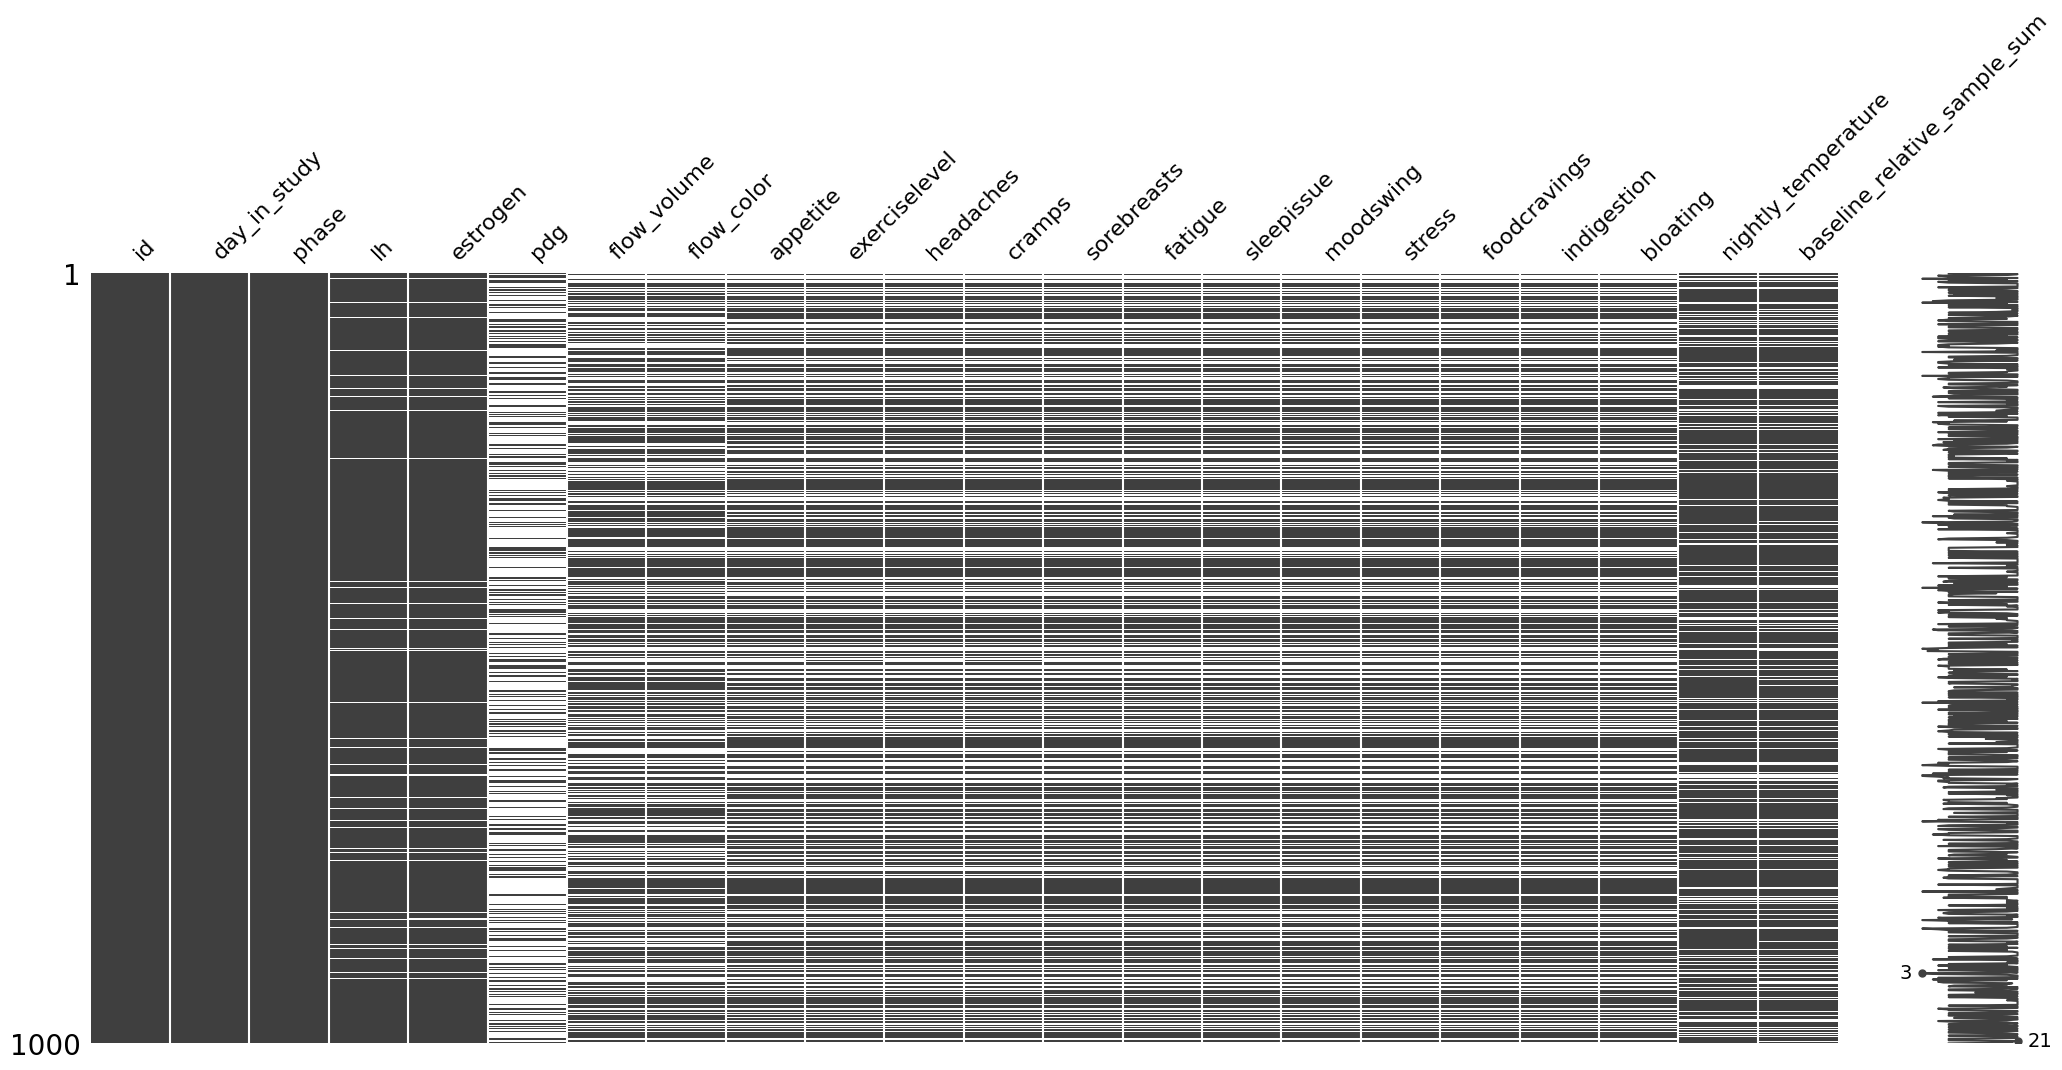

In [8]:
df = dfs.get('../mcphases/merged/symptoms_hormones.csv')
if df is not None:
    print(df.select_dtypes(include='number').describe().T)
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0)
    plt.title('Symptoms & Hormones: Numeric correlation heatmap')
    plt.show()
    try:
        msno.matrix(df.sample(min(1000,len(df))))
    except Exception:
        pass

## EDA: Stress/Recovery — correlations and missingness

                                count         mean         std        min  \
id                            13737.0    27.957705   13.994025   1.000000   
day_in_study                  13737.0   681.905438  388.120159   1.000000   
mean_bpm                      13521.0    79.211347    8.064107  54.234770   
mean_rmssd                    12917.0    56.942441   30.574071   0.000000   
mean_coverage                 12917.0     0.965577    0.011766   0.777000   
mean_low_frequency            12917.0  1399.587446  959.031578  72.551455   
mean_high_frequency           12917.0  1013.393147  985.580712  28.255048   
resting_hr                    13737.0    63.751213   22.451326   0.000000   
stress_score                  10713.0    76.737165    7.441416   0.000000   
stress_sleep_points           10713.0     7.193153   11.100182   0.000000   
stress_responsiveness_points  10713.0     6.927378   10.661694   0.000000   
stress_exertion_points        10713.0     9.542052   14.683572   0.000000   

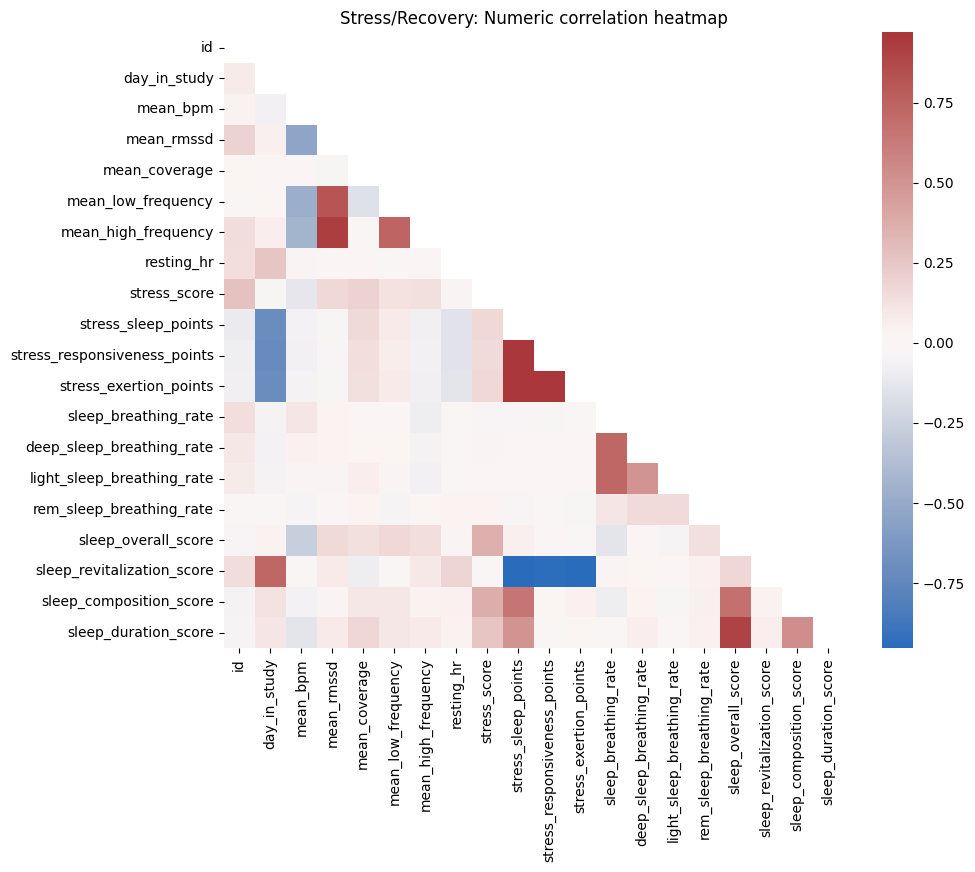

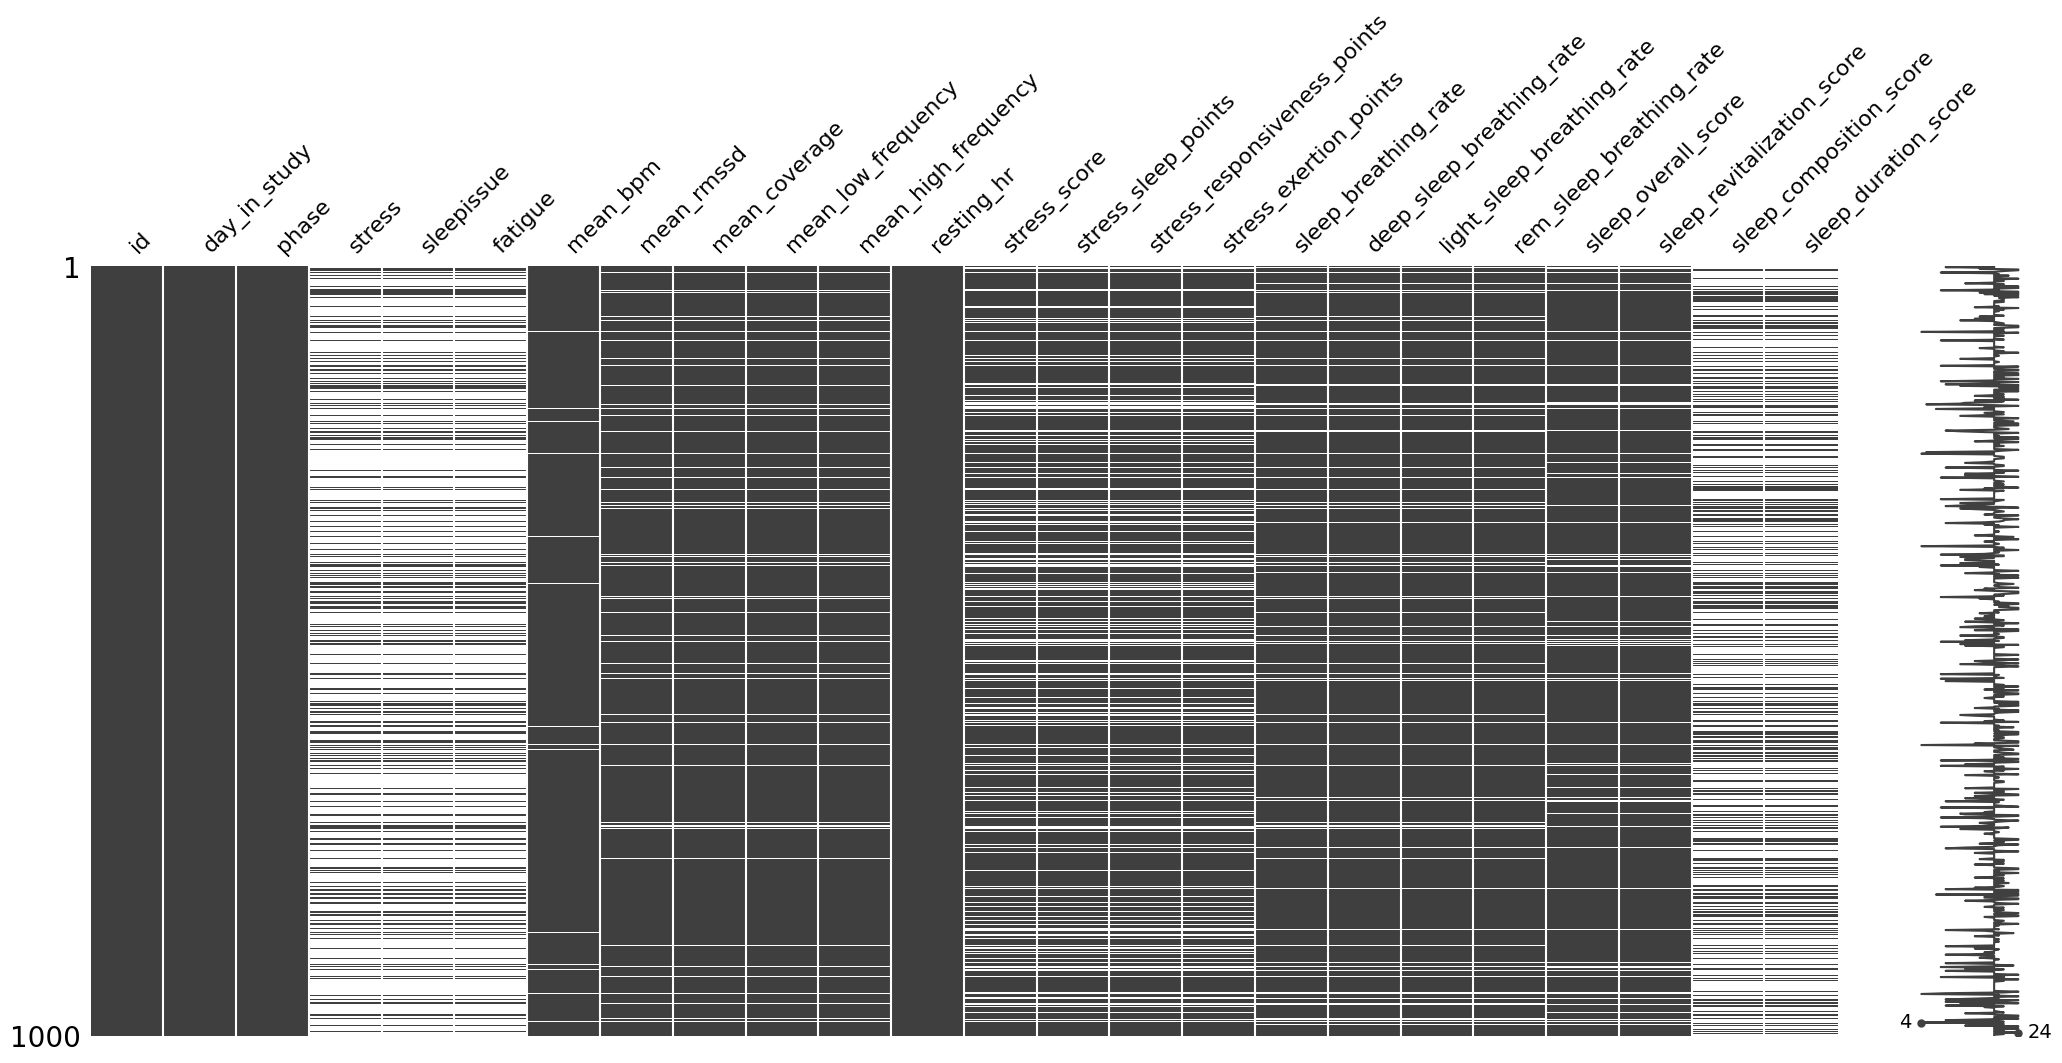

In [9]:
df = dfs.get('../mcphases/merged/stress_recovery.csv')
if df is not None:
    print(df.select_dtypes(include='number').describe().T)
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0)
    plt.title('Stress/Recovery: Numeric correlation heatmap')
    plt.show()
    try:
        msno.matrix(df.sample(min(1000,len(df))))
    except Exception:
        pass

## EDA: Background — correlations and missingness

                                      count         mean           std  \
id                                  11482.0    27.913865     14.070770   
birth_year                          11482.0  2001.762759      2.415468   
age_of_first_menarche               11482.0    11.815189      1.202219   
height_2022                          6088.0   162.657819      5.171324   
weight_2022                          6797.0    58.459276      9.889747   
height_2024                          3985.0   168.520176      6.109594   
weight_2024                          5578.0    69.681355     22.258537   
day_in_study                        11482.0   648.350200    403.973781   
demographic_vo2_max                 11482.0  7637.170478  10256.376712   
demographic_vo2_max_error           11482.0     3.000000      0.000000   
filtered_demographic_vo2_max        11482.0  7822.533262  10199.147630   
filtered_demographic_vo2_max_error  11482.0     0.444357      0.373152   

                                     

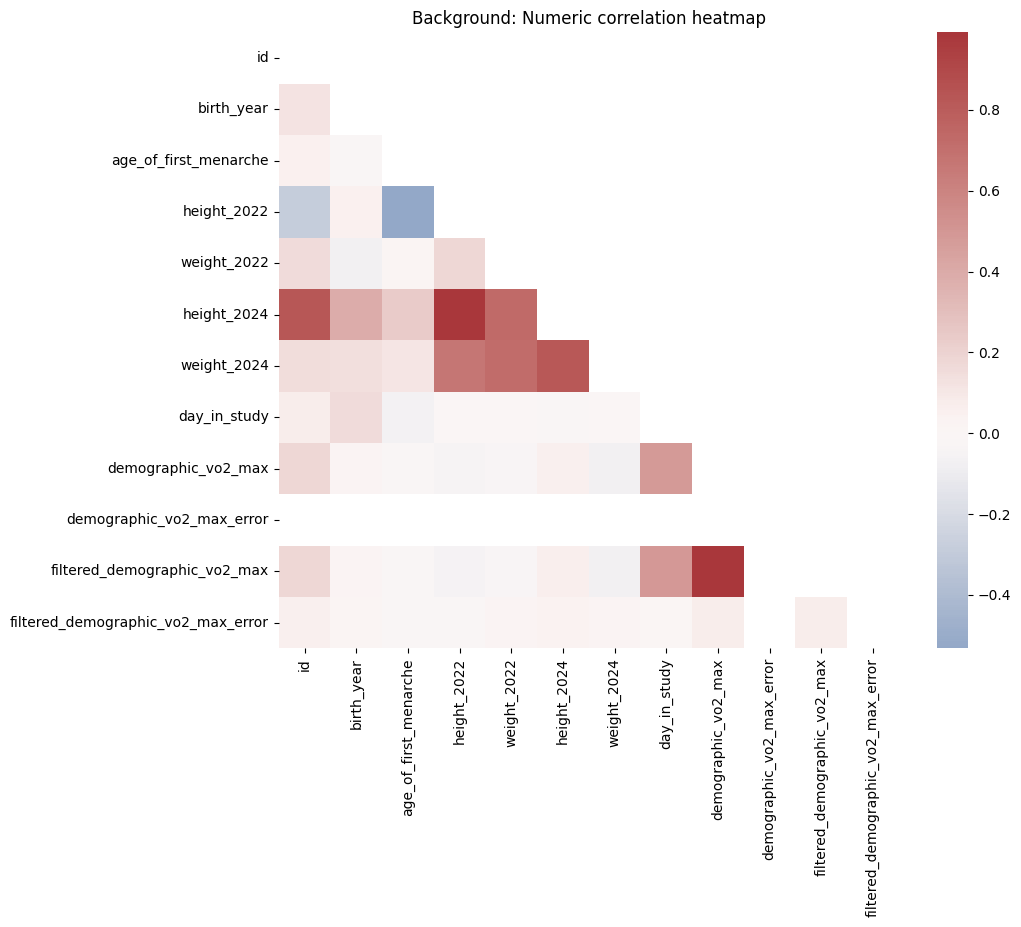

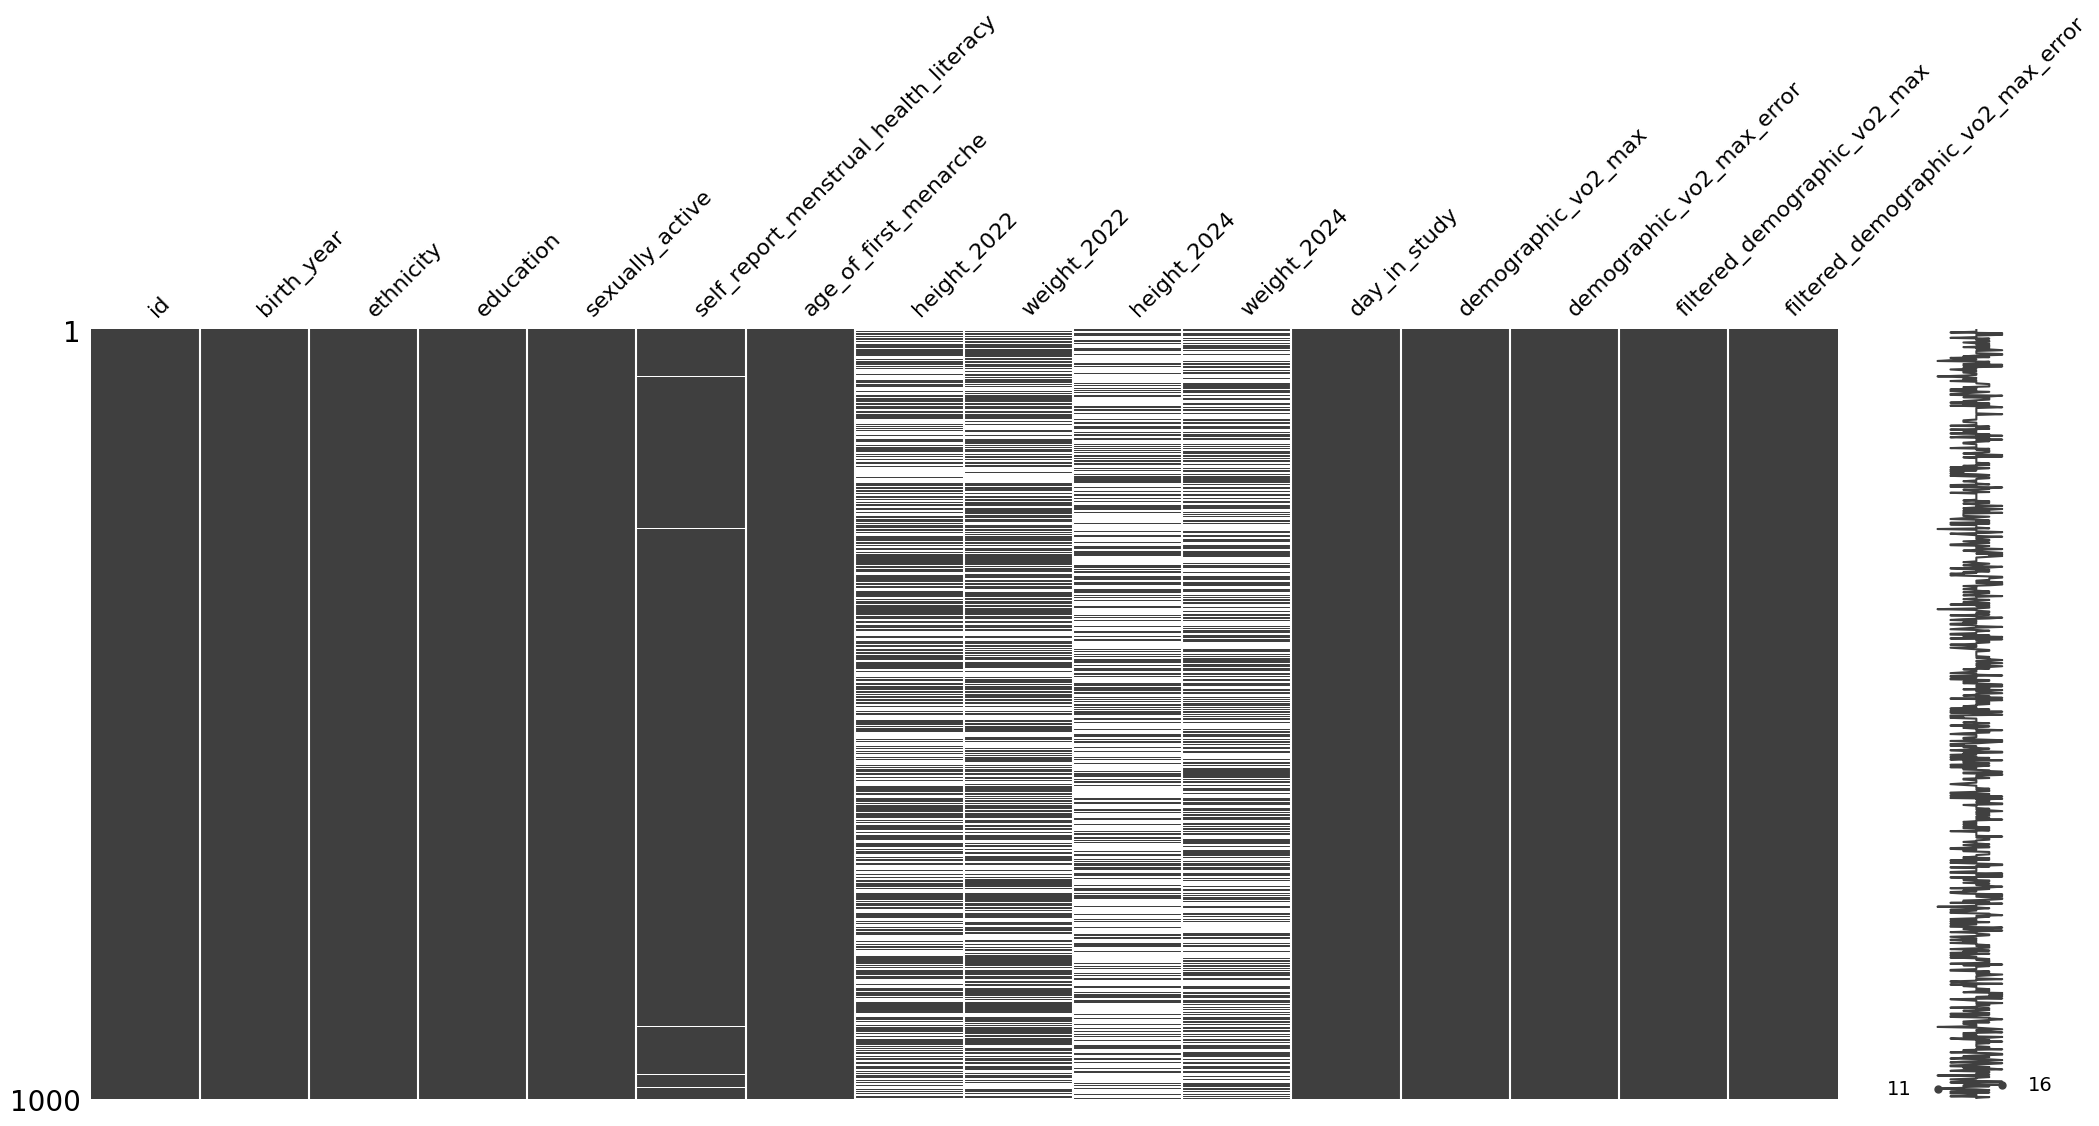

In [10]:
df = dfs.get('../mcphases/merged/background.csv')
if df is not None:
    print(df.select_dtypes(include='number').describe().T)
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0)
    plt.title('Background: Numeric correlation heatmap')
    plt.show()
    try:
        msno.matrix(df.sample(min(1000,len(df))))
    except Exception:
        pass